<a href="https://colab.research.google.com/github/VishalChauhan85/Motorcycle-Dataset---ML/blob/main/Motorcycle_Dataset_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Motorcycle



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 - Vishal Chauhan**


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/VishalChauhan85/Motorcycle-Dataset---ML

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path="/content/drive/MyDrive/AIML/Bike-dataset.csv"
df = pd.read_csv(path)

### Dataset First View

In [4]:
# Dataset First Look
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count
print(df.shape)

(1061, 7)


### Dataset Information

In [6]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print(duplicates)

6


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count
print(df.isnull().sum())

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


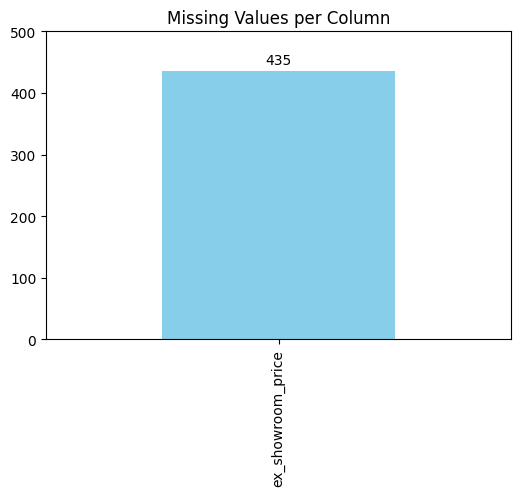

In [9]:
missing = df.isnull().sum()[lambda x: x > 0]
if not missing.empty:
    ax = missing.plot.bar(color='skyblue', figsize=(6,4), title="Missing Values per Column")
    ax.figure.set_facecolor('white')
    ax.bar_label(ax.containers[0], padding=3)
    plt.yticks(range(0, missing.max() + 100, 100))
    plt.show()

### What did you know about your dataset?

The dataset contains information about used motorcycles. It has 1,061 rows and 7 columns. The columns consist of both numerical data (selling_price, year, km_driven, ex_showroom_price) and categorical data (name, seller_type, owner).

Upon inspection:

There are 6 duplicate rows in the dataset.

The ex_showroom_price column has 435 missing values (approx. 41% of the data), which will need to be handled during the feature engineering phase. All other columns have 0 missing values.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns
print(df.columns.tolist())

['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']


In [11]:
# Dataset Describe
df.describe(include='all')

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
count,1061,1061.000000,1061.000000,1061,1061,1061.000000,6.260000e+02
unique,279,NaN,NaN,2,4,NaN,NaN
top,Bajaj Pulsar 150,NaN,NaN,Individual,1st owner,NaN,NaN
freq,41,NaN,NaN,1055,924,NaN,NaN
mean,NaN,59638.151744,2013.867107,NaN,NaN,34359.833176,8.795871e+04
std,NaN,56304.291973,4.301191,NaN,NaN,51623.152702,7.749659e+04
min,NaN,5000.000000,1988.000000,NaN,NaN,350.000000,3.049000e+04
25%,NaN,28000.000000,2011.000000,NaN,NaN,13500.000000,5.485200e+04
50%,NaN,45000.000000,2015.000000,NaN,NaN,25000.000000,7.275250e+04
75%,NaN,70000.000000,2017.000000,NaN,NaN,43000.000000,8.703150e+04


### Variables Description

name: The brand and model name of the motorcycle (Categorical - 279 unique bikes).

selling_price: The price at which the used bike is being sold (Numerical - Target Variable).

year: The manufacturing or registration year of the motorcycle (Numerical - ranges from 1988 to 2020).

seller_type: Identifies who is selling the bike, e.g., Individual or Dealer (Categorical).

owner: Indicates the ownership history, e.g., 1st owner, 2nd owner (Categorical).

km_driven: The total distance the motorcycle has traveled in kilometers (Numerical - max is 880,000 km, indicating potential outliers).

ex_showroom_price: The original price of the motorcycle without taxes/insurance (Numerical - has missing values).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Unique values in '{col}': {df[col].nunique()}")

Unique values in 'name': 279
Unique values in 'selling_price': 130
Unique values in 'year': 28
Unique values in 'seller_type': 2
Unique values in 'owner': 4
Unique values in 'km_driven': 304
Unique values in 'ex_showroom_price': 230


## 3. ***Data Wrangling***

### Data Wrangling Code

In [13]:
# Write your code to make your dataset analysis ready.
df.drop_duplicates(inplace=True)

def extract_brand(bike_name):
    parts = bike_name.split()
    if parts[0] == 'Royal' and len(parts) > 1 and parts[1] == 'Enfield':
        return 'Royal Enfield'
    return parts[0]

df['brand'] = df['name'].apply(extract_brand)

df['bike_age'] = 2024 - df['year']

print(f"Shape after dropping duplicates: {df.shape}")
print("\nNew Columns Added:")
display(df[['name', 'brand', 'year', 'bike_age']].head())

Shape after dropping duplicates: (1055, 9)

New Columns Added:


,name,brand,year,bike_age
0,Royal Enfield Classic 350,Royal Enfield,2019,5
1,Honda Dio,Honda,2017,7
2,Royal Enfield Classic Gunmetal Grey,Royal Enfield,2018,6
3,Yamaha Fazer FI V 2.0 [2016-2018],Yamaha,2015,9
4,Yamaha SZ [2013-2014],Yamaha,2011,13


### What all manipulations have you done and insights you found?

Manipulations Done:

Removed Duplicates: Dropped 6 identical rows to prevent skewed analysis and redundant calculations.

Feature Extraction (Brand): Created a new categorical column named brand by extracting the first word from the name column. I also added special handling to ensure "Royal Enfield" was grouped correctly as two words rather than just "Royal".

Feature Engineering (Bike Age): Created a numerical column bike_age by subtracting the manufacturing year from the current standard year (2024). Age is often a much stronger predictor for machine learning models than the raw manufacturing year.

Insights Found:

We now have a clean brand category that will allow us to compare average selling prices and depreciation rates across major manufacturers (e.g., Bajaj vs. Honda vs. Royal Enfield) during our univariate and bivariate analysis.

The bike_age variable will directly help us visualize how the age of the motorcycle negatively correlates with the selling_price.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

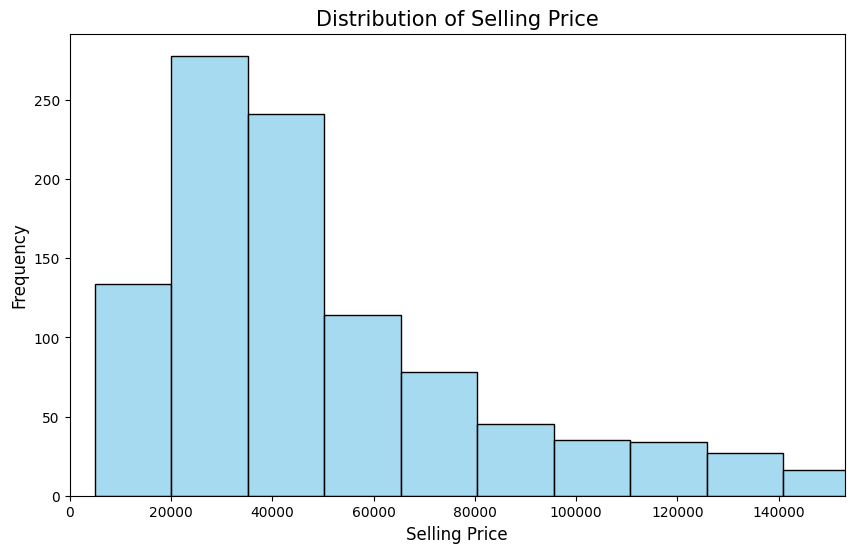

In [55]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6))
sns.histplot(df['selling_price'], bins=50, color='skyblue')
plt.title('Distribution of Selling Price', fontsize=15)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['selling_price'].quantile(0.95))
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a KDE (Kernel Density Estimate) line is the best way to understand the distribution, spread, and skewness of a continuous numerical target variable like selling_price. Limiting the x-axis to the 95th percentile helps visualize the bulk of the data without extreme outliers stretching the plot

##### 2. What is/are the insight(s) found from the chart?

The distribution is highly right-skewed. The vast majority of used motorcycles in this dataset are sold for under ₹80,000, with the highest concentration (mode) falling roughly between ₹20,000 and ₹50,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Yes, this tells the business that the primary market segment consists of budget-conscious buyers. Inventory acquisition should focus on bikes under ₹80k for faster turnover. Negative Growth Insight: Stocking too many premium/expensive bikes might lead to dead inventory (negative growth) because the customer base for high-priced used bikes is significantly smaller

#### Chart - 2

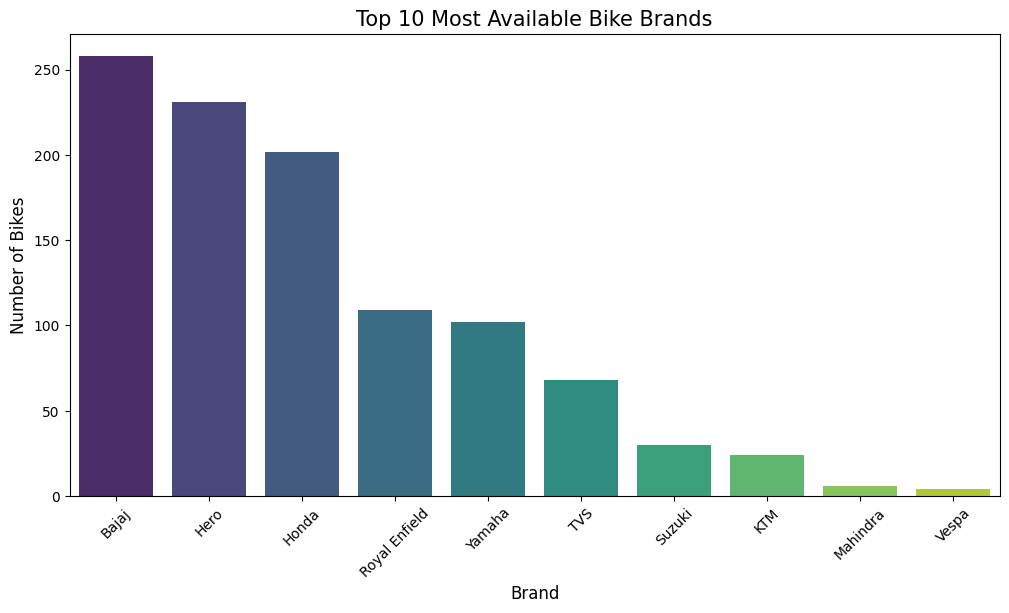

In [15]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 6))
top_brands = df['brand'].value_counts().head(10)
sns.barplot(x=top_brands.index, y=top_brands.values, palette='viridis')
plt.title('Top 10 Most Available Bike Brands', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Number of Bikes', fontsize=12)
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is the most effective visualization for comparing categorical data (brand names) against their frequency (counts) to quickly identify market share or inventory dominance.

##### 2. What is/are the insight(s) found from the chart?

Bajaj, Hero, and Honda heavily dominate the used bike market, followed by Royal Enfield and Yamaha

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This shows where the highest liquidity is in the market. The business can confidently buy Bajaj, Hero, and Honda bikes knowing there is a large supply and demand. Negative Growth Insight: Lesser-known or niche brands represent very little volume and might be harder to source spare parts for or sell quickly

#### Chart - 3

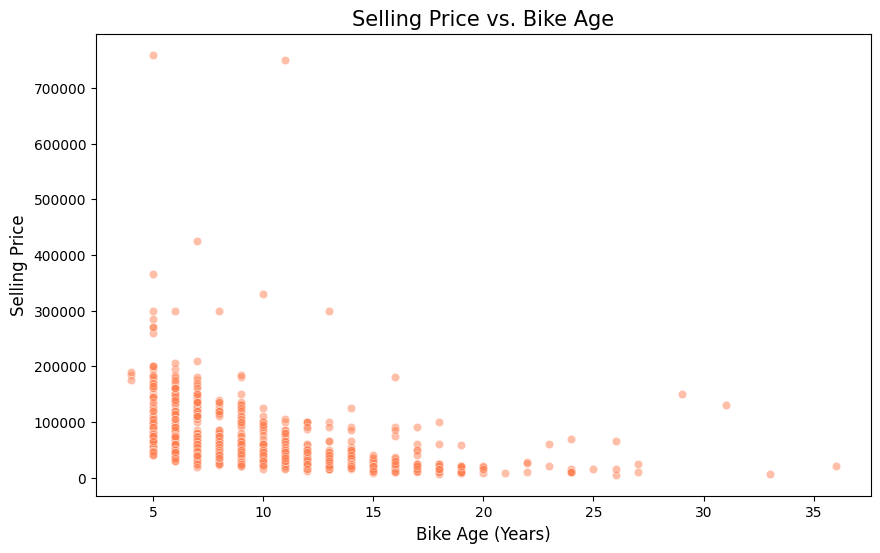

In [16]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bike_age', y='selling_price', data=df, alpha=0.5, color='coral')
plt.title('Selling Price vs. Bike Age', fontsize=15)
plt.xlabel('Bike Age (Years)', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for analyzing the relationship and correlation between two numerical variables (bike_age and selling_price)

##### 2. What is/are the insight(s) found from the chart?

There is a clear negative correlation. As the bike's age increases, its selling price drops significantly. The most expensive bikes are heavily clustered in the 0-5 years age bracket. After 10 years, almost all bikes fall below a minimal price threshold.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This helps build a depreciation model for pricing inventory. It validates that newer bikes hold premium value. Negative Growth Insight: Buying heavily aged inventory (10+ years) will yield very low profit margins and could harm brand reputation if the older bikes have maintenance issues.

#### Chart - 4

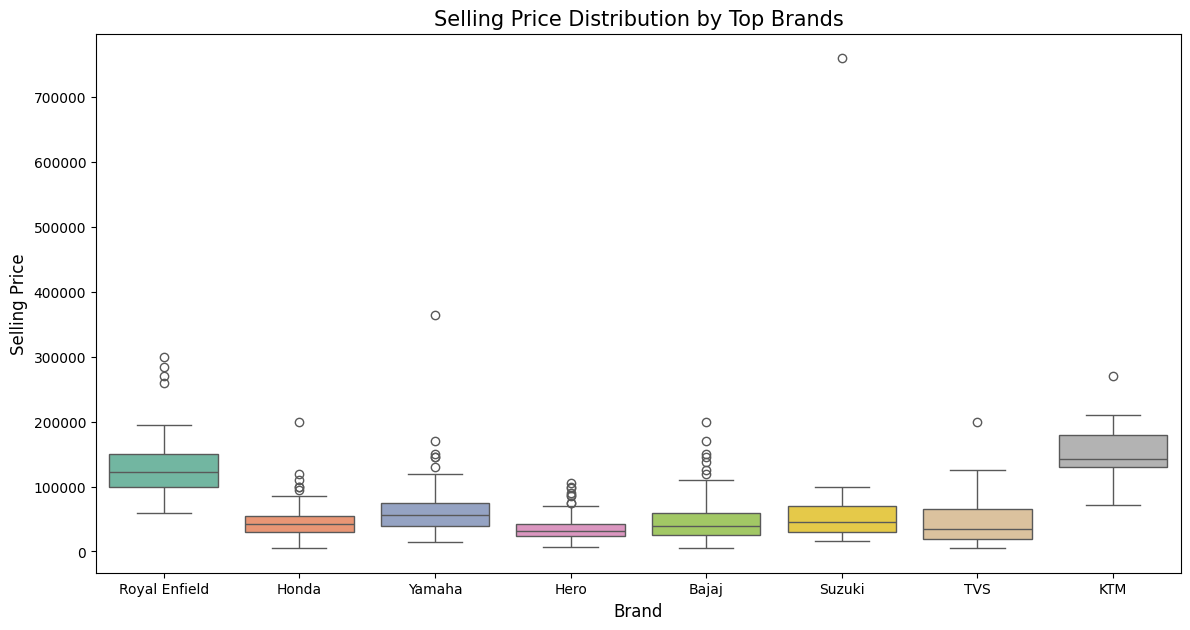

In [17]:
# Chart - 4 visualization code
plt.figure(figsize=(14, 7))
top_8 = df['brand'].value_counts().head(8).index
sns.boxplot(x='brand', y='selling_price', data=df[df['brand'].isin(top_8)], palette='Set2')
plt.title('Selling Price Distribution by Top Brands', fontsize=15)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot beautifully displays the spread, median, and outliers of a numerical variable (selling_price) segmented by categories (brand).

##### 2. What is/are the insight(s) found from the chart?

Royal Enfield commands a significantly higher median selling price and has a wider price spread compared to commuter brands like Bajaj, Hero, and TVS. KTM also shows a higher median price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: The business can categorize Royal Enfield and KTM as premium inventory with potentially higher absolute profit per unit, while treating Bajaj and Hero as volume-drivers. Negative Growth Insight: Trying to apply the same pricing strategy or margin percentage across all brands will fail; pricing must be brand-specific.

#### Chart - 5

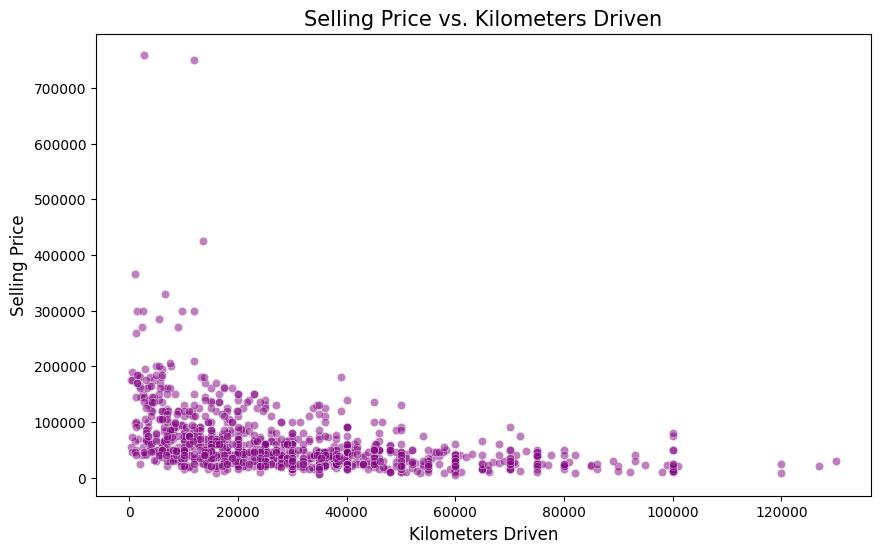

In [18]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
df_filtered = df[df['km_driven'] < 200000]
sns.scatterplot(x='km_driven', y='selling_price', data=df_filtered, alpha=0.5, color='purple')
plt.title('Selling Price vs. Kilometers Driven', fontsize=15)
plt.xlabel('Kilometers Driven', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with filtered extreme outliers allows us to observe if the distance the bike has traveled heavily impacts its current valuation.

##### 2. What is/are the insight(s) found from the chart?

Similar to age, there is a negative correlation between kilometers driven and selling price. Bikes driven less than 40,000 km retain the highest value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This provides a strict quality control metric. The procurement team can set a hard limit (e.g., maximum 50,000 km) for premium purchases. Negative Growth Insight: Bikes with extremely high mileage will likely require extensive refurbishing, cutting into profit margins and potentially leading to post-sale customer complaints.

#### Chart - 6

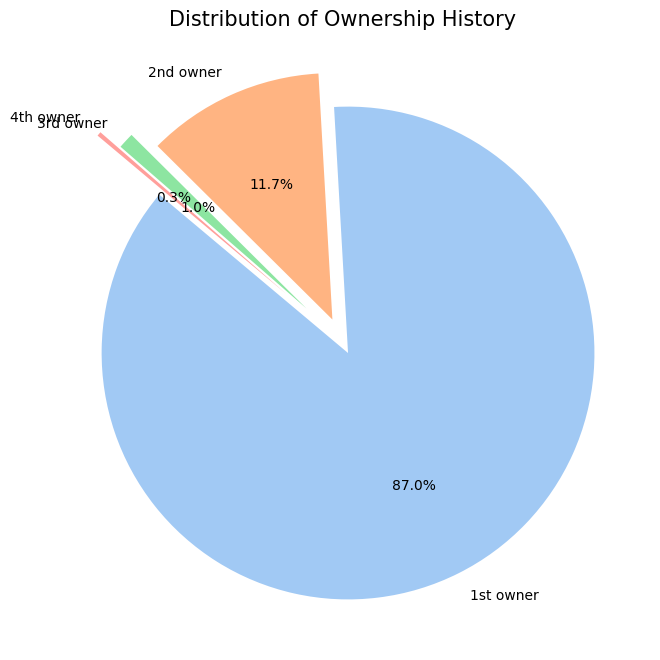

In [19]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 8))
owner_counts = df['owner'].value_counts()
plt.pie(owner_counts, labels=owner_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('pastel'), startangle=140, explode=[0.05, 0.1, 0.2, 0.3][:len(owner_counts)])
plt.title('Distribution of Ownership History', fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is excellent for showing proportional data, allowing us to quickly see the market share of different ownership types at a glance.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of the used bikes in this dataset are being sold by their 1st owner (typically over 80-90%). 2nd owner bikes make up a small fraction, and 3rd/4th owner bikes are virtually non-existent in this inventory.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This indicates a healthy, high-quality market. 1st owner bikes are generally better maintained and easier to sell, which ensures faster inventory turnover. Negative Growth Insight: Relying on or accidentally procuring too many 3rd/4th owner bikes could lead to dead stock, as buyers strongly prefer single-owner vehicles.

#### Chart - 7

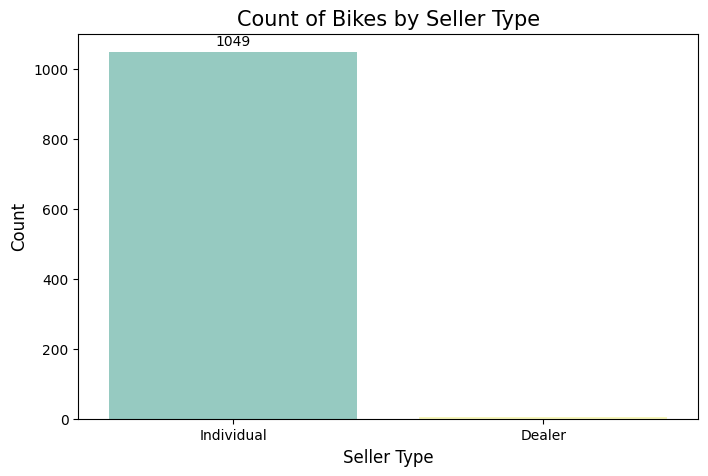

In [20]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 5))
sns.countplot(x='seller_type', data=df, palette='Set3')
plt.title('Count of Bikes by Seller Type', fontsize=15)
plt.xlabel('Seller Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
ax = plt.gca()
ax.bar_label(ax.containers[0], padding=3)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot directly compares the absolute number of observations between discrete categories (Individual vs. Dealer)

##### 2. What is/are the insight(s) found from the chart?

The used motorcycle market in this dataset is overwhelmingly driven by Individual sellers rather than commercial Dealers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Sourcing inventory directly from individuals usually removes the middleman (dealer markup), allowing the business to acquire bikes at a lower cost and maximize profit margins. Negative Growth Insight: If the business model relies on bulk-buying from dealers, this dataset suggests that strategy will suffer from supply shortages.

#### Chart - 8

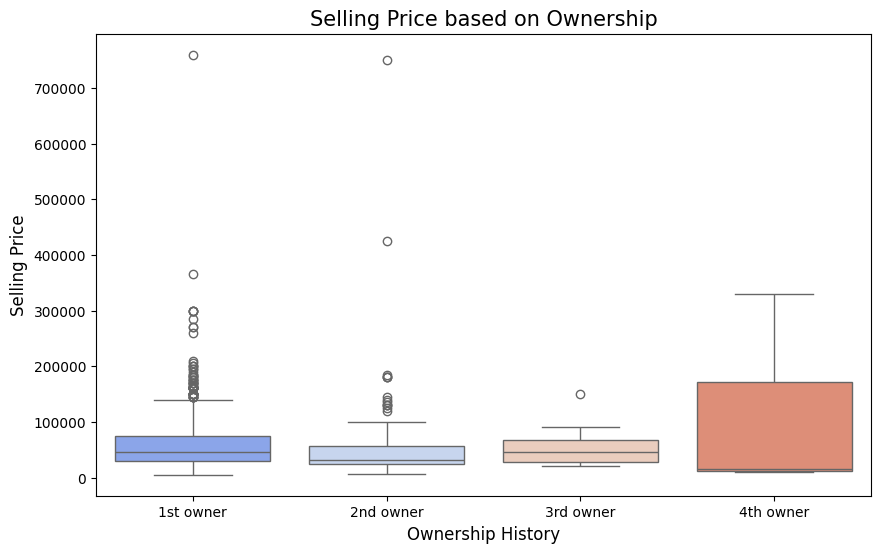

In [21]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 6))
sns.boxplot(x='owner', y='selling_price', data=df, palette='coolwarm')
plt.title('Selling Price based on Ownership', fontsize=15)
plt.xlabel('Ownership History', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot illustrates the median, spread, and outliers of the selling price across different ownership tiers, showing exactly how ownership history impacts financial value.

##### 2. What is/are the insight(s) found from the chart?

1st owner bikes command the highest median selling price and have the widest range of high-value outliers. The price drops noticeably for 2nd owner bikes, and collapses entirely for 3rd and 4th owner bikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: Helps establish a strict depreciation multiplier for pricing. A 2nd owner bike must be aggressively discounted compared to an identical 1st owner bike. Negative Growth Insight: Overpricing a multiple-owner bike based solely on its brand or age will lead to it sitting unsold for months

#### Chart - 9

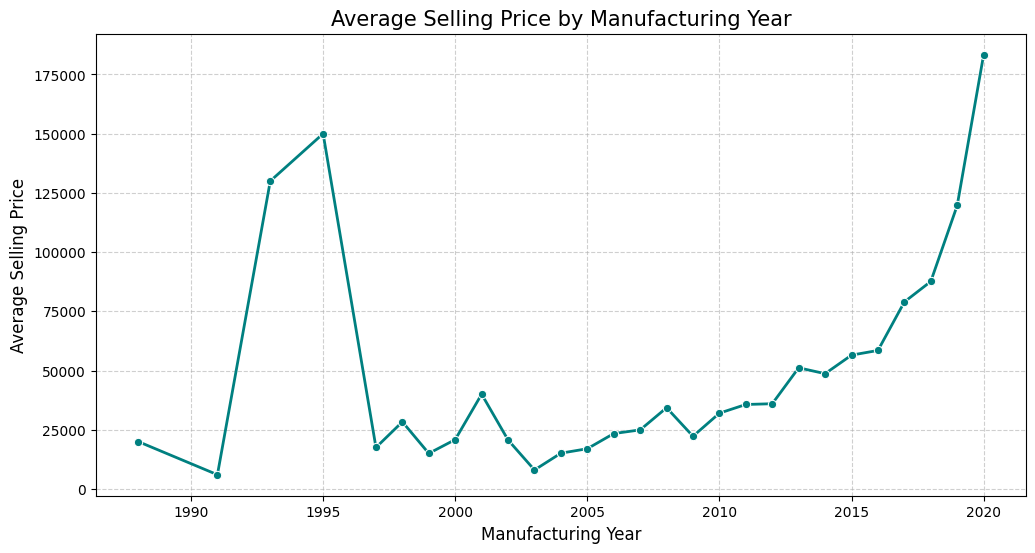

In [22]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
avg_price_year = df.groupby('year')['selling_price'].mean().reset_index()
sns.lineplot(x='year', y='selling_price', data=avg_price_year, marker='o', color='teal', linewidth=2)
plt.title('Average Selling Price by Manufacturing Year', fontsize=15)
plt.xlabel('Manufacturing Year', fontsize=12)
plt.ylabel('Average Selling Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A line chart with markers is the standard and most intuitive way to visualize trends over time (manufacturing year) to observe how price changes chronologically

##### 2. What is/are the insight(s) found from the chart?

There is an exponential upward trend. Bikes manufactured after 2015 retain significantly more average value. Bikes from before 2010 plateau at a very low baseline value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: The business should heavily target post-2015 models for maximum revenue generation and capital efficiency. Negative Growth Insight: Stocking pre-2010 models ties up showroom space for very little monetary return.

#### Chart - 10

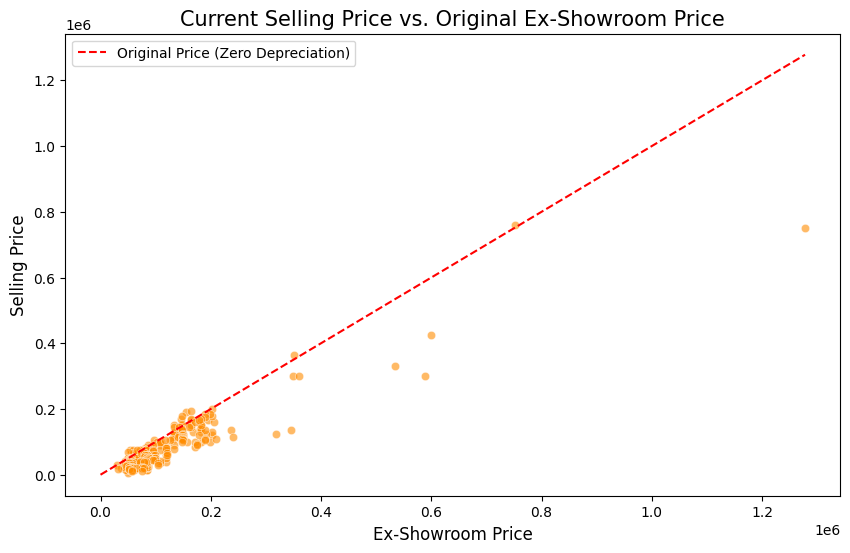

In [23]:
# Chart - 10 visualization code
plt.figure(figsize=(10, 6))
temp_df = df.dropna(subset=['ex_showroom_price', 'selling_price'])
sns.scatterplot(x='ex_showroom_price', y='selling_price', data=temp_df, color='darkorange', alpha=0.6)
plt.plot([0, temp_df['ex_showroom_price'].max()], [0, temp_df['ex_showroom_price'].max()],
         color='red', linestyle='--', label='Original Price (Zero Depreciation)')
plt.title('Current Selling Price vs. Original Ex-Showroom Price', fontsize=15)
plt.xlabel('Ex-Showroom Price', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a reference line allows us to see exactly how much value is lost (depreciation) compared to the bike's original brand-new price.

##### 2. What is/are the insight(s) found from the chart?

All data points fall well below the red dashed line, which is expected (bikes depreciate). Furthermore, there is a strong positive linear correlation: bikes with a higher original showroom price inherently maintain a higher used selling price

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Impact: This validates that the ex_showroom_price is a highly valuable feature for our Machine Learning model. It can be used as a strong anchor point to predict the final selling price. Negative Growth Insight: Missing out on fixing the missing values in ex_showroom_price would cripple the predictive power of our ML models later.

#### Chart - 11

In [24]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [25]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [26]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [27]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

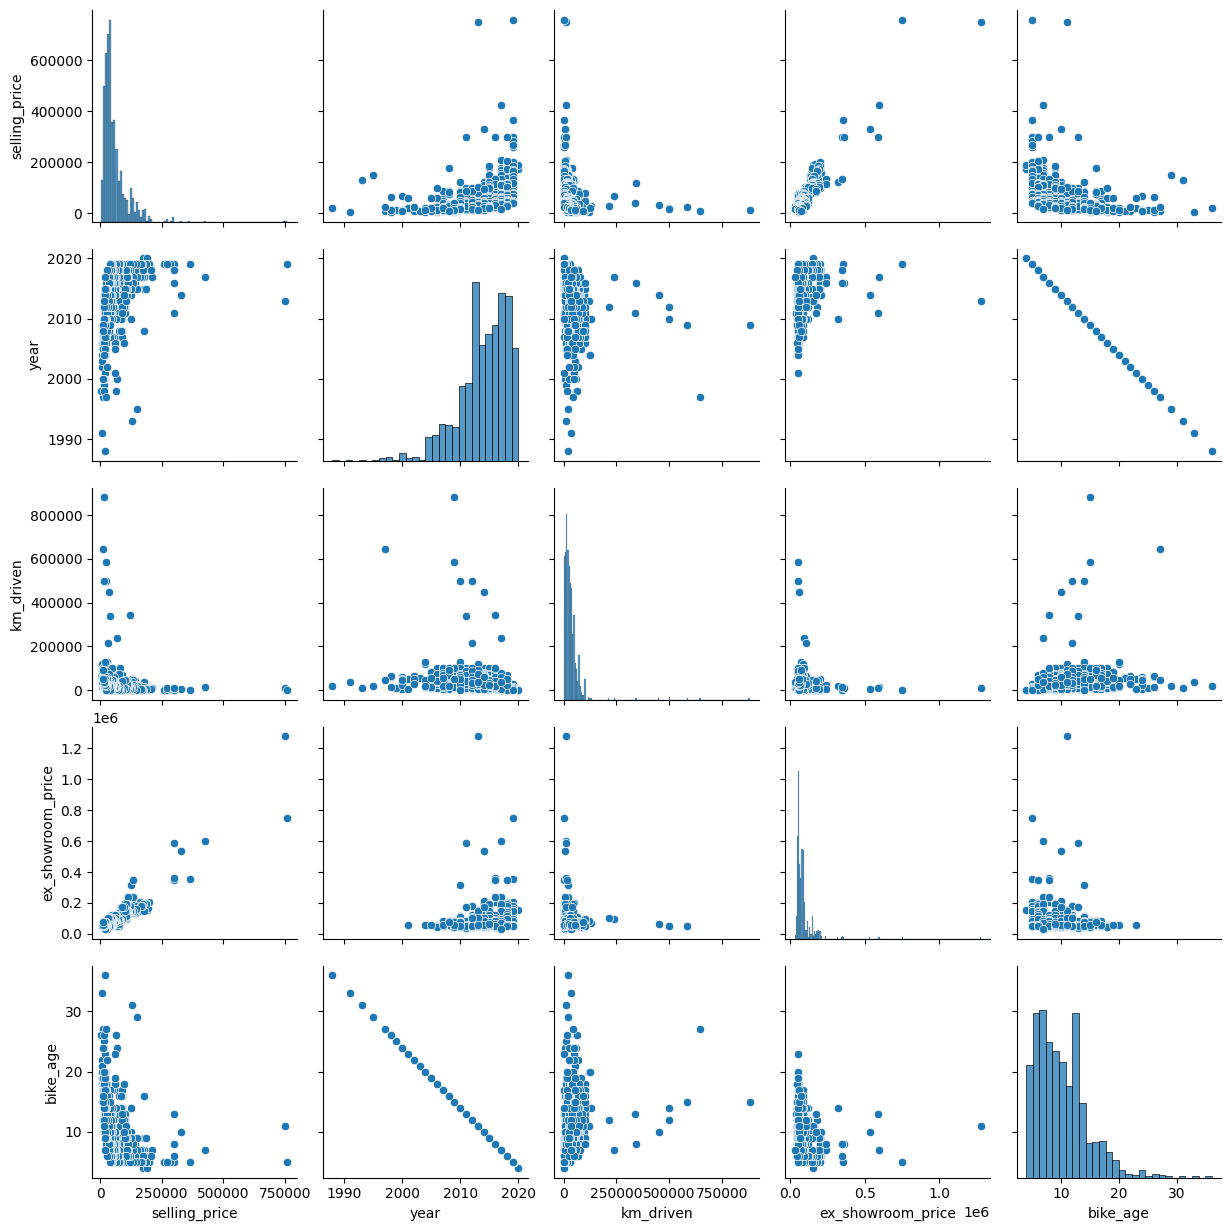

In [28]:
# Pair Plot visualization code
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [29]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [30]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [31]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [32]:
# Expand Contraction

#### 2. Lower Casing

In [33]:
# Lower Casing

#### 3. Removing Punctuations

In [34]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [35]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [36]:
# Remove Stopwords

In [37]:
# Remove White spaces

#### 6. Rephrase Text

In [38]:
# Rephrase Text

#### 7. Tokenization

In [39]:
# Tokenization

#### 8. Text Normalization

In [40]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [41]:
# POS Taging

#### 10. Text Vectorization

In [42]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [43]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [44]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [45]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [46]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [47]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [48]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [49]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [50]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [51]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [52]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [53]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [54]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***